# Data & Packages

In [1]:
# Main packages
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Time constants
minutes_per_week = 7 * 24 * 60 
n_weeks = 8     
eight_weeks_seconds = n_weeks * minutes_per_week * 60

In [3]:
# Load data and filter for human users & first 8 weeks of data
df = (
    pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz", has_header=False, separator=",",
                new_columns=['time','src_user','dest_user','src_comp','dest_comp',
                              'auth_type','logon_type','auth_orientation','outcome'])
    .filter(pl.col('src_user').str.starts_with('U'))
    .filter(pl.col('time') < eight_weeks_seconds)
    .collect(engine='streaming')
)

In [4]:
# Distinct (user, minute) points 
user_minutes = (
    df.select(
        'src_user',
        minute = pl.col('time') // 60,
    )
    .unique()
)

# Functions

In [5]:
# Jaccard index for consecutive weeks
def jaccard_by_week(agg_hours):

    agg_minutes = round(agg_hours * 60)  
   
    points = (
        user_minutes.select(
            'src_user',
            week = pl.col('minute') // minutes_per_week,
            relative_bucket = (pl.col('minute') % minutes_per_week) // agg_minutes,
        )
        .unique()
    )

    jaccards = []

    for week in range(n_weeks - 1):

        w_curr = points.filter(pl.col('week') == week)
        w_next = points.filter(pl.col('week') == week + 1)

        overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner')

        union = len(w_curr) + len(w_next) - len(overlap)

        jaccards.append(len(overlap) / union)

    return np.array(jaccards)

# JACCARD

In [6]:
# Aggregation levels in hours
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1, '2 h': 2,
          '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12,
          '24 h': 24}

In [7]:
# Jaccard values for each aggregation level
results = {name: jaccard_by_week(h) for name, h in levels.items()}

In [8]:
# Boxplot setup
level_names = list(levels.keys())
x_positions = np.arange(1, len(level_names) + 1)
xtick_labels = ['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h']

boxstyle = dict(patch_artist=True,
                 boxprops=dict(facecolor='tab:blue', alpha=0.35, edgecolor='tab:blue'),
                 medianprops=dict(color='tab:blue', lw=1.5),
                 whiskerprops=dict(color='tab:blue'),
                 capprops=dict(color='tab:blue'))

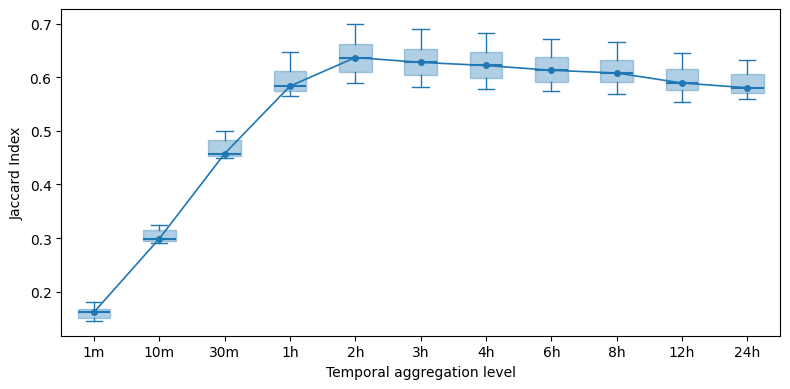

In [9]:
# Plot of jaccards as boxplots with median trend line
fig, ax = plt.subplots(figsize=(8, 4))

jaccard = [results[name] for name in level_names]

ax.boxplot(jaccard, positions=x_positions, widths=0.5, showfliers=True, **boxstyle)

jaccard_medians = [np.median(a) for a in jaccard]
ax.plot(x_positions, jaccard_medians, color='tab:blue', lw=1.2, marker='o', ms=4, zorder=3, label='Median')

ax.set_xticks(x_positions)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('Temporal aggregation level')
ax.set_ylabel('Jaccard Index')
plt.tight_layout()
plt.show()

In [10]:
# # Save results to CSV
# import pandas as pd

# dummy = pd.DataFrame(results)                     
# dummy.index = [f"{w+1}-{w+2}" for w in range(n_weeks- 1)]   
# dummy.index.name = "Week pair"

# col_order = ['1 min','10 min','30 min','1 h','2 h','3 h','4 h','6 h','8 h','12 h','24 h']
# dummy = dummy[col_order]

# dummy.to_csv("jaccard_by_aggregation.csv")